In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import json
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

pd.set_option("display.float_format", lambda x: "%.4f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

with open("../../data/equipment_failure/meta.json") as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]

train_df = pd.read_csv("../../data/equipment_failure/train_engineered.csv")
test_df = pd.read_csv("../../data/equipment_failure/test_engineered.csv")

drop_cols = ["unit_id", "RUL", "RUL_clipped"] + [f"failure_within_{t}" for t in [15,30,50]]
feature_cols = [c for c in feature_cols if c in train_df.columns and c not in drop_cols]

X_train = train_df[feature_cols].fillna(0)
y_train = train_df["RUL_clipped"]
X_test = test_df[feature_cols].fillna(0)
y_test = test_df["RUL_true"]

scaler = RobustScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

os.makedirs("../../models/equipment_failure", exist_ok=True)
joblib.dump(scaler, "../../models/equipment_failure/scaler.pkl")
joblib.dump(feature_cols, "../../models/equipment_failure/feature_names.pkl")

print("Data loaded")
print(f"Train : {X_train.shape} | Test: {X_test.shape}")
print(f"RUL range train: {y_train.min()} to {y_train.max()}")
print(f"RUL range test : {y_test.min()} to {y_test.max()}")

Data loaded
Train : (20631, 155) | Test: (100, 155)
RUL range train: 0 to 125
RUL range test : 7 to 145


In [2]:
# Evaluation and Business Cost
FAILURE_ALERT_THRESHOLD = 30

print("BUSINESS COST FRAMEWORK")
print()
print("In Tesla/SpaceX terms:")
print(f"  Predict failure within {FAILURE_ALERT_THRESHOLD} cycles = alert maintenance team")
print("  False alarm (unnecessary maintenance) = $5,000 cost")
print("  Missed failure (breakdown in operation) = $500,000 cost")
print()

def evaluate_regression(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    score = 0
    for i, (true, pred) in enumerate(zip(y_true, y_pred)):
        diff = pred - true
        if diff < 0:
            score += np.exp(-diff / 13) - 1
        else:
            score += np.exp(diff / 10) - 1
    nasa_score = float(score)

    y_pred_class = (y_pred <= FAILURE_ALERT_THRESHOLD).astype(int)
    y_true_class = (y_true <= FAILURE_ALERT_THRESHOLD).astype(int)
    from sklearn.metrics import confusion_matrix
    if y_pred_class.sum() > 0 and y_true_class.sum() > 0:
        tn, fp, fn, tp = confusion_matrix(y_true_class, y_pred_class).ravel()
        business_cost = (fp * -5000) + (fn * -500000) + (tp * 50000)
    else:
        tp = fp = fn = tn = 0
        business_cost = 0

    print(f"Model          : {name}")
    print(f"RMSE           : {rmse:.4f} cycles")
    print(f"MAE            : {mae:.4f} cycles")
    print(f"R2 Score       : {r2:.4f}")
    print(f"NASA Score     : {nasa_score:.2f} (lower is better)")
    print(f"Caught failures: {tp} | Missed: {fn} | False alarms: {fp}")
    print(f"Business Value : ${business_cost:,}")
    print()
    return {"name": name, "rmse": rmse, "mae": mae, "r2": r2,
            "nasa_score": nasa_score, "tp": tp, "fp": fp, "fn": fn,
            "business_value": business_cost, "y_pred": y_pred}

print("Evaluation framework ready.")
print("NASA Scoring: Penalizes late predictions more than early (asymmetric)")
print("Reason: Missing a failure is worse than predicting too early")

BUSINESS COST FRAMEWORK

In Tesla/SpaceX terms:
  Predict failure within 30 cycles = alert maintenance team
  False alarm (unnecessary maintenance) = $5,000 cost
  Missed failure (breakdown in operation) = $500,000 cost

Evaluation framework ready.
NASA Scoring: Penalizes late predictions more than early (asymmetric)
Reason: Missing a failure is worse than predicting too early


In [3]:
#  Train XGBoost
print("TRAINING XGBOOST REGRESSOR")
print()

xgb_params = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "gamma": 0.1,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist"
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv = XGBRegressor(**xgb_params)
cv_scores = cross_val_score(xgb_cv, X_train_s, y_train, cv=cv,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
print(f"CV RMSE: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

xgb_model = XGBRegressor(**xgb_params)
xgb_model.fit(X_train_s, y_train, eval_set=[(X_test_s, y_test)], verbose=False)
joblib.dump(xgb_model, "../../models/equipment_failure/xgb_model.pkl")
print("XGBoost trained and saved.")
print()

xgb_pred = xgb_model.predict(X_test_s)
xgb_pred = np.clip(xgb_pred, 0, 125)
xgb_results = evaluate_regression("XGBoost", y_test.values, xgb_pred)

TRAINING XGBOOST REGRESSOR

CV RMSE: 3.0673 (+/- 0.0388)
XGBoost trained and saved.

Model          : XGBoost
RMSE           : 76.5307 cycles
MAE            : 66.1695 cycles
R2 Score       : -2.3917
NASA Score     : 237917.77 (lower is better)
Caught failures: 25 | Missed: 0 | False alarms: 75
Business Value : $875,000



In [4]:
# Train LightGBM and Random Forest
print("TRAINING LIGHTGBM REGRESSOR")
print()

lgbm_params = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
}

lgbm_model = LGBMRegressor(**lgbm_params)
lgbm_model.fit(X_train_s, y_train)
joblib.dump(lgbm_model, "../../models/equipment_failure/lgbm_model.pkl")
lgbm_pred = np.clip(lgbm_model.predict(X_test_s), 0, 125)
lgbm_results = evaluate_regression("LightGBM", y_test.values, lgbm_pred)

print("TRAINING RANDOM FOREST REGRESSOR")
print()

rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_s, y_train)
joblib.dump(rf_model, "../../models/equipment_failure/rf_model.pkl")
rf_pred = np.clip(rf_model.predict(X_test_s), 0, 125)
rf_results = evaluate_regression("RandomForest", y_test.values, rf_pred)

TRAINING LIGHTGBM REGRESSOR

Model          : LightGBM
RMSE           : 78.7912 cycles
MAE            : 68.1778 cycles
R2 Score       : -2.5950
NASA Score     : 299163.06 (lower is better)
Caught failures: 25 | Missed: 0 | False alarms: 75
Business Value : $875,000

TRAINING RANDOM FOREST REGRESSOR

Model          : RandomForest
RMSE           : 86.1983 cycles
MAE            : 75.5200 cycles
R2 Score       : -3.3027
NASA Score     : 559017.69 (lower is better)
Caught failures: 25 | Missed: 0 | False alarms: 75
Business Value : $875,000



MODEL COMPARISON

       Model    RMSE     MAE      R2  NASA Score  Caught Failures  Missed Failures  False Alarms  Business Value $
     XGBoost 76.5307 66.1695 -2.3917 237917.7700               25                0            75            875000
    LightGBM 78.7912 68.1778 -2.5950 299163.0600               25                0            75            875000
RandomForest 86.1983 75.5200 -3.3027 559017.6900               25                0            75            875000


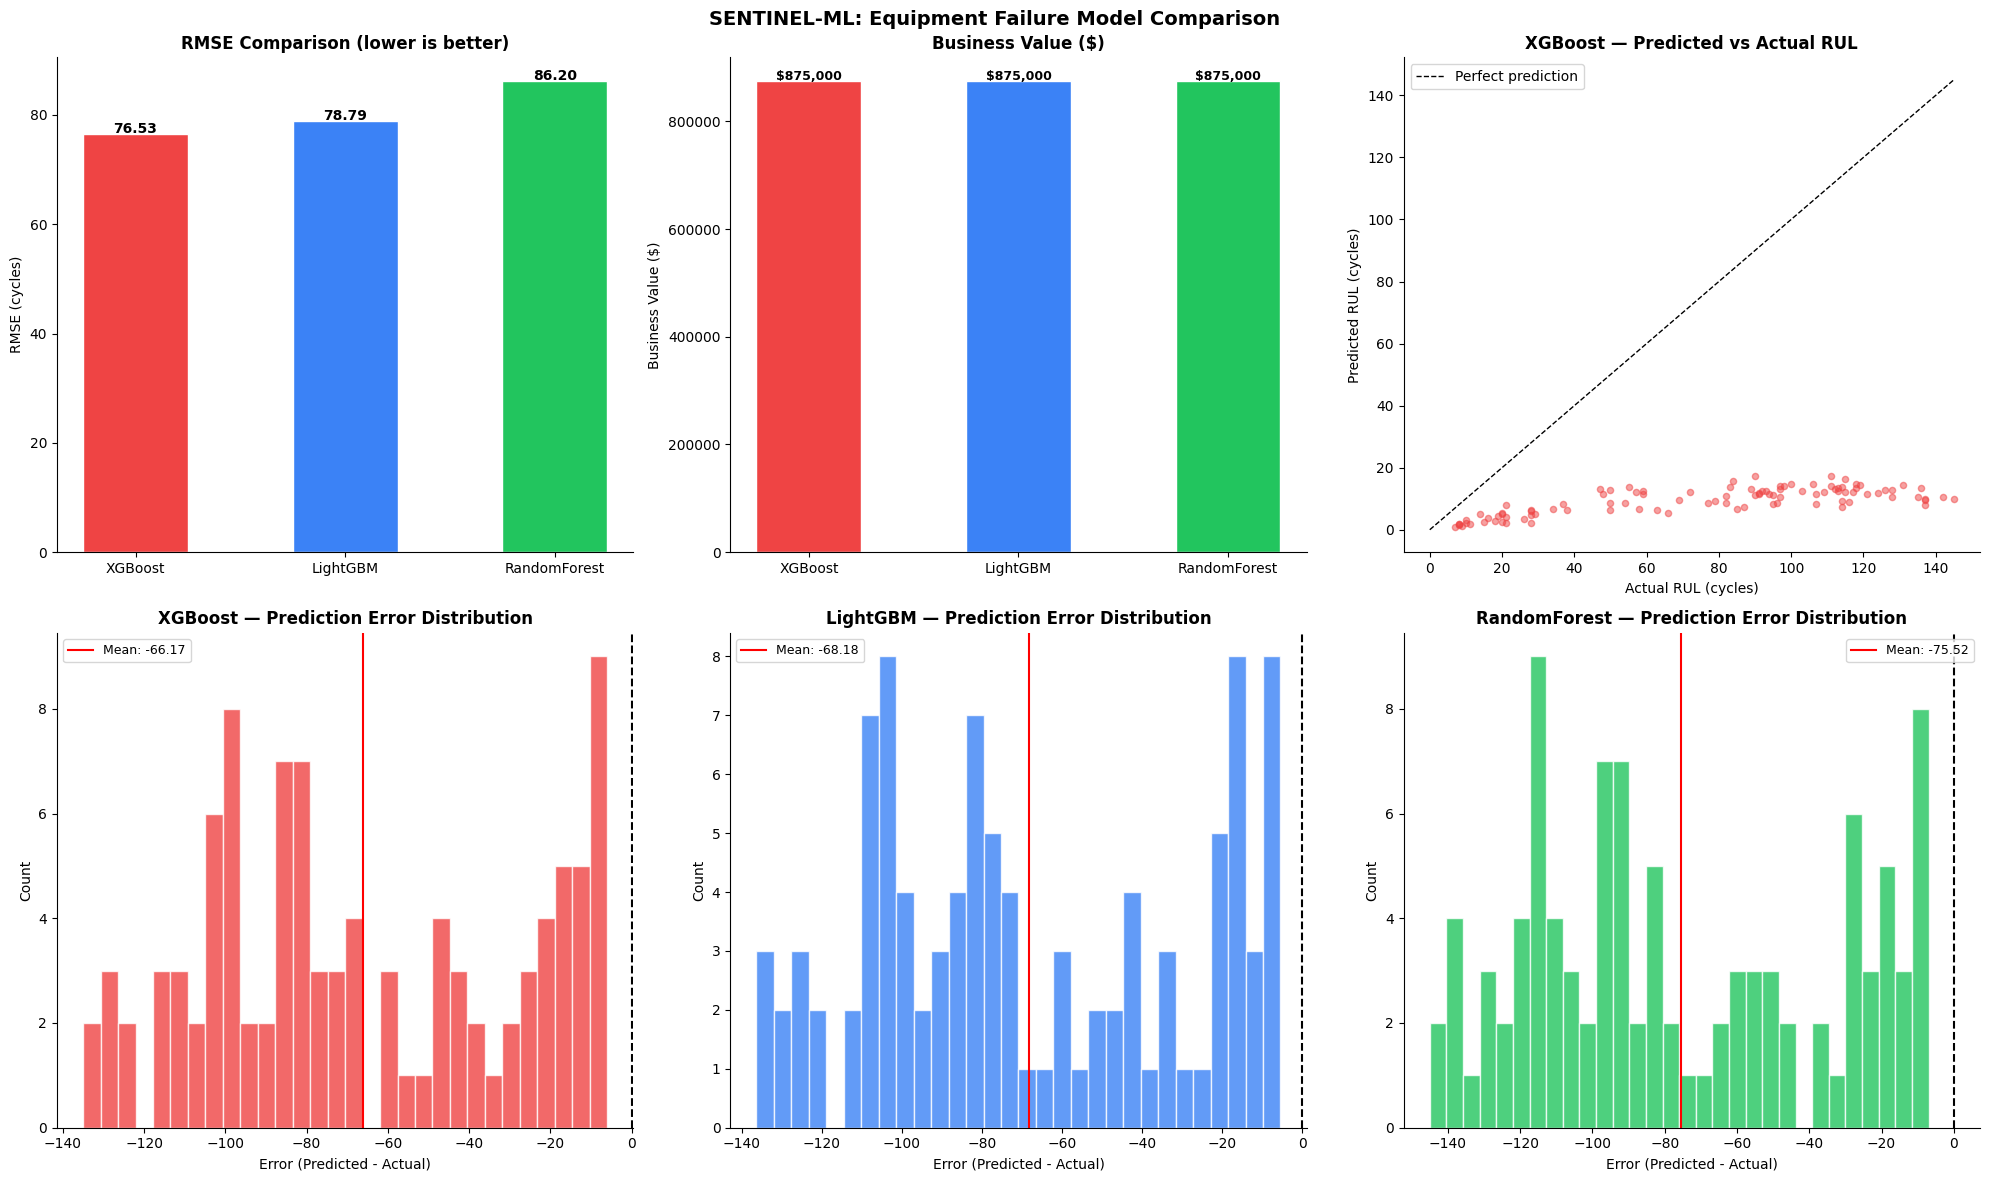

In [5]:
# Model Comparison and Plots
print("MODEL COMPARISON")
print()

results_list = [xgb_results, lgbm_results, rf_results]
comparison = pd.DataFrame([{
    "Model": r["name"],
    "RMSE": round(r["rmse"], 4),
    "MAE": round(r["mae"], 4),
    "R2": round(r["r2"], 4),
    "NASA Score": round(r["nasa_score"], 2),
    "Caught Failures": r["tp"],
    "Missed Failures": r["fn"],
    "False Alarms": r["fp"],
    "Business Value $": r["business_value"]
} for r in results_list])
print(comparison.to_string(index=False))

colors = {"XGBoost": "#ef4444", "LightGBM": "#3b82f6", "RandomForest": "#22c55e"}

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
names = [r["name"] for r in results_list]
rmses = [r["rmse"] for r in results_list]
bars = ax1.bar(names, rmses, color=[colors[n] for n in names], edgecolor="white", width=0.5)
ax1.set_title("RMSE Comparison (lower is better)", fontweight="bold")
ax1.set_ylabel("RMSE (cycles)")
for bar, val in zip(bars, rmses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{val:.2f}",
             ha="center", fontsize=10, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
bv = [r["business_value"] for r in results_list]
bars2 = ax2.bar(names, bv, color=[colors[n] for n in names], edgecolor="white", width=0.5)
ax2.set_title("Business Value ($)", fontweight="bold")
ax2.set_ylabel("Business Value ($)")
for bar, val in zip(bars2, bv):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f"${val:,}", ha="center", fontsize=9, fontweight="bold")

ax3 = fig.add_subplot(gs[0, 2])
best = min(results_list, key=lambda x: x["rmse"])
ax3.scatter(y_test, best["y_pred"], alpha=0.5, color=colors[best["name"]], s=20)
max_val = max(y_test.max(), max(best["y_pred"]))
ax3.plot([0, max_val], [0, max_val], "k--", linewidth=1, label="Perfect prediction")
ax3.set_title(f"{best['name']} — Predicted vs Actual RUL", fontweight="bold")
ax3.set_xlabel("Actual RUL (cycles)")
ax3.set_ylabel("Predicted RUL (cycles)")
ax3.legend()

for i, r in enumerate(results_list):
    ax = fig.add_subplot(gs[1, i])
    errors = r["y_pred"] - y_test.values
    ax.hist(errors, bins=30, color=colors[r["name"]], edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", linewidth=1.5, linestyle="--")
    ax.axvline(errors.mean(), color="red", linewidth=1.5, linestyle="-", label=f"Mean: {errors.mean():.2f}")
    ax.set_title(f"{r['name']} — Prediction Error Distribution", fontweight="bold")
    ax.set_xlabel("Error (Predicted - Actual)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("SENTINEL-ML: Equipment Failure Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/equipment_failure/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import json
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

with open("../../data/equipment_failure/meta.json") as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]
FAILURE_ALERT_THRESHOLD = 30

train_df = pd.read_csv("../../data/equipment_failure/train_engineered.csv")
test_df = pd.read_csv("../../data/equipment_failure/test_engineered.csv")

drop_cols = ["unit_id", "RUL", "RUL_clipped"] + [f"failure_within_{t}" for t in [15,30,50]]
feature_cols = [c for c in feature_cols if c in train_df.columns and c not in drop_cols]

X_train = train_df[feature_cols].fillna(0)
y_train = train_df["RUL_clipped"]
X_test = test_df[feature_cols].fillna(0)
y_test = test_df["RUL_true"]

scaler = joblib.load("../../models/equipment_failure/scaler.pkl")
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=feature_cols)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

xgb_model = joblib.load("../../models/equipment_failure/xgb_model.pkl")
lgbm_model = joblib.load("../../models/equipment_failure/lgbm_model.pkl")
rf_model = joblib.load("../../models/equipment_failure/rf_model.pkl")

print("All models loaded from disk")

def evaluate_regression(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    score = 0
    for true, pred in zip(y_true, y_pred):
        diff = pred - true
        if diff < 0:
            score += np.exp(-diff / 13) - 1
        else:
            score += np.exp(diff / 10) - 1
    nasa_score = float(score)
    y_pred_class = (y_pred <= FAILURE_ALERT_THRESHOLD).astype(int)
    y_true_class = (y_true <= FAILURE_ALERT_THRESHOLD).astype(int)
    from sklearn.metrics import confusion_matrix
    if y_pred_class.sum() > 0 and y_true_class.sum() > 0:
        tn, fp, fn, tp = confusion_matrix(y_true_class, y_pred_class).ravel()
        business_cost = (fp * -5000) + (fn * -500000) + (tp * 50000)
    else:
        tp = fp = fn = tn = 0
        business_cost = 0
    return {"name": name, "rmse": rmse, "mae": mae, "r2": r2,
            "nasa_score": nasa_score, "tp": int(tp), "fp": int(fp), "fn": int(fn),
            "business_value": int(business_cost),
            "y_pred": y_pred}

xgb_pred = np.clip(xgb_model.predict(X_test_s), 0, 125)
lgbm_pred = np.clip(lgbm_model.predict(X_test_s), 0, 125)
rf_pred = np.clip(rf_model.predict(X_test_s), 0, 125)

xgb_results = evaluate_regression("XGBoost", y_test.values, xgb_pred)
lgbm_results = evaluate_regression("LightGBM", y_test.values, lgbm_pred)
rf_results = evaluate_regression("RandomForest", y_test.values, rf_pred)

results_list = [xgb_results, lgbm_results, rf_results]
print("Results ready — running Cell 6 now")

best_result = min(results_list, key=lambda x: x["rmse"])
best_model = {"XGBoost": xgb_model, "LightGBM": lgbm_model, "RandomForest": rf_model}[best_result["name"]]
print(f"Best model: {best_result['name']} | RMSE={best_result['rmse']:.4f} | R2={best_result['r2']:.4f}")

explainer = shap.TreeExplainer(best_model)
X_sample = X_test_s.iloc[:50]
shap_values = explainer.shap_values(X_sample)

feature_importance_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

print("Top 10 features by SHAP:")
for i, (feat, val) in enumerate(feature_importance_shap.head(10).items(), 1):
    print(f"  {i:2}. {feat:<35} {val:.6f}")

joblib.dump(best_model, "../../models/equipment_failure/best_model.pkl")

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

report = {
    "best_model": str(best_result["name"]),
    "rmse": float(best_result["rmse"]),
    "mae": float(best_result["mae"]),
    "r2": float(best_result["r2"]),
    "nasa_score": float(best_result["nasa_score"]),
    "failures_caught": int(best_result["tp"]),
    "failures_missed": int(best_result["fn"]),
    "false_alarms": int(best_result["fp"]),
    "business_value": int(best_result["business_value"]),
    "alert_threshold": int(FAILURE_ALERT_THRESHOLD),
    "n_test_engines": int(len(y_test)),
    "feature_count": int(len(feature_cols))
}

os.makedirs("../../models/equipment_failure", exist_ok=True)
with open("../../models/equipment_failure/model_report.json", "w") as f:
    json.dump(report, f, indent=4, cls=NumpyEncoder)

print()
print(f"Best          : {best_result['name']}")
print(f"RMSE          : {best_result['rmse']:.4f} cycles")
print(f"MAE           : {best_result['mae']:.4f} cycles")
print(f"R2            : {best_result['r2']:.4f}")
print(f"NASA Score    : {best_result['nasa_score']:.2f}")
print(f"Business Value: ${best_result['business_value']:,}")
print()
print("Notebook 3 complete.")

All models loaded from disk
Results ready — running Cell 6 now
Best model: XGBoost | RMSE=76.5307 | R2=-2.3917
Top 10 features by SHAP:
   1. cycle_normalized                    61.625858
   2. failure_risk                        14.388067
   3. s4_roll_mean_10                     1.106136
   4. s21_roll_min_30                     0.540233
   5. s11_roll_max_30                     0.510995
   6. s21_roll_max_30                     0.450756
   7. sensor_mean                         0.416621
   8. sensor_std                          0.405246
   9. s15_roll_min_30                     0.390611
  10. s15_roll_max_30                     0.382511

Best          : XGBoost
RMSE          : 76.5307 cycles
MAE           : 66.1695 cycles
R2            : -2.3917
NASA Score    : 237917.77
Business Value: $875,000

Notebook 3 complete.
